In [1]:
# %%
# Cel·la 1: Configuració inicial
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import Point, LineString
from scipy.spatial import KDTree
import time
from math import sin, cos, radians

%matplotlib inline

print("✅ Llibreries carregades")

✅ Llibreries carregades


In [2]:
# %%
# Cel·la 2: Funcions bàsiques
def find_nearest_edge(graph, point):
    """Troba la vora (edge) més propera a un punt (x, y)"""
    edges = graph.edges(keys=True, data=True)
    min_dist = float('inf')
    nearest_edge = None
    projected_point = None
    
    for u, v, key, data in edges:
        if 'geometry' in data:
            line = data['geometry']
        else:
            line = LineString([
                Point(graph.nodes[u]['x'], graph.nodes[u]['y']),
                Point(graph.nodes[v]['x'], graph.nodes[v]['y'])
            ])
        
        dist = line.distance(Point(point))
        if dist < min_dist:
            min_dist = dist
            nearest_edge = (u, v, key)
            projected_point = line.interpolate(line.project(Point(point)))
    
    return nearest_edge, min_dist, projected_point

def get_nearest_node_on_edge(graph, edge, projected_point):
    """Retorna el node (u o v) més proper al punt projectat"""
    u, v, key = edge
    u_point = Point(graph.nodes[u]['x'], graph.nodes[u]['y'])
    v_point = Point(graph.nodes[v]['x'], graph.nodes[v]['y'])
    
    if projected_point.distance(u_point) < projected_point.distance(v_point):
        return u
    else:
        return v

def rotate_points(points, angle_deg, center=(0, 0)):
    """Rota un conjunt de punts al voltant d'un centre"""
    angle_rad = radians(angle_deg)
    cos_a = cos(angle_rad)
    sin_a = sin(angle_rad)
    
    cx, cy = center
    rotated = []
    
    for x, y in points:
        # Traslladar al centre
        x_trans = x - cx
        y_trans = y - cy
        
        # Rotar
        x_rot = x_trans * cos_a - y_trans * sin_a
        y_rot = x_trans * sin_a + y_trans * cos_a
        
        # Traslladar de tornada
        rotated.append((x_rot + cx, y_rot + cy))
    
    return np.array(rotated)

print("✅ Funcions definides")

✅ Funcions definides


In [3]:
# %%
# Cel·la 3: Carregar dades i definir lletra 'H'
print("Carregant xarxa de l'Eixample...")
area = "Eixample, Barcelona, Spain"
G = ox.graph_from_place(area, network_type='walk', simplify=True)
G_proj = ox.project_graph(G)

# Centre de la zona
center_x, center_y = np.array([(G_proj.nodes[n]['x'], G_proj.nodes[n]['y']) 
                              for n in G_proj.nodes()]).mean(axis=0)

# Mida de la lletra
letter_width = 300  # metres
letter_height = 300  # metres

# Definir lletra 'H' en coordenades relatives (0-1)
def generate_letter_H():
    """Punts per dibuixar la lletra 'H'"""
    points = [
        # Pal esquerra
        (0.0, 0.0),
        (0.0, 1.0),
        # Pal dret
        (1.0, 0.0),
        (1.0, 1.0),
        # Barra central (esquerra a dreta)
        (0.0, 0.5),
        (1.0, 0.5),
        # Tancar (opcional - tornar a inici)
        (0.0, 0.0)
    ]
    return points

# Escalar punts a mida i posició real
points_H_relative = generate_letter_H()
points_H_base = []

for x_rel, y_rel in points_H_relative:
    x_abs = center_x + (x_rel - 0.5) * letter_width
    y_abs = center_y + (y_rel - 0.5) * letter_height
    points_H_base.append((x_abs, y_abs))

points_H_base = np.array(points_H_base)

print(f"Centre: ({center_x:.0f}, {center_y:.0f})")
print(f"Lletra 'H' base definida: {len(points_H_base)} punts")
print(f"Mida: {letter_width}x{letter_height} metres")

Carregant xarxa de l'Eixample...
Centre: (430151, 4582572)
Lletra 'H' base definida: 7 punts
Mida: 300x300 metres


Analitzant orientació dels carrers...
Orientacions principals dels carrers:
  1: 42.5°
  2: 47.5°
  3: 132.5°
  4: 137.5°


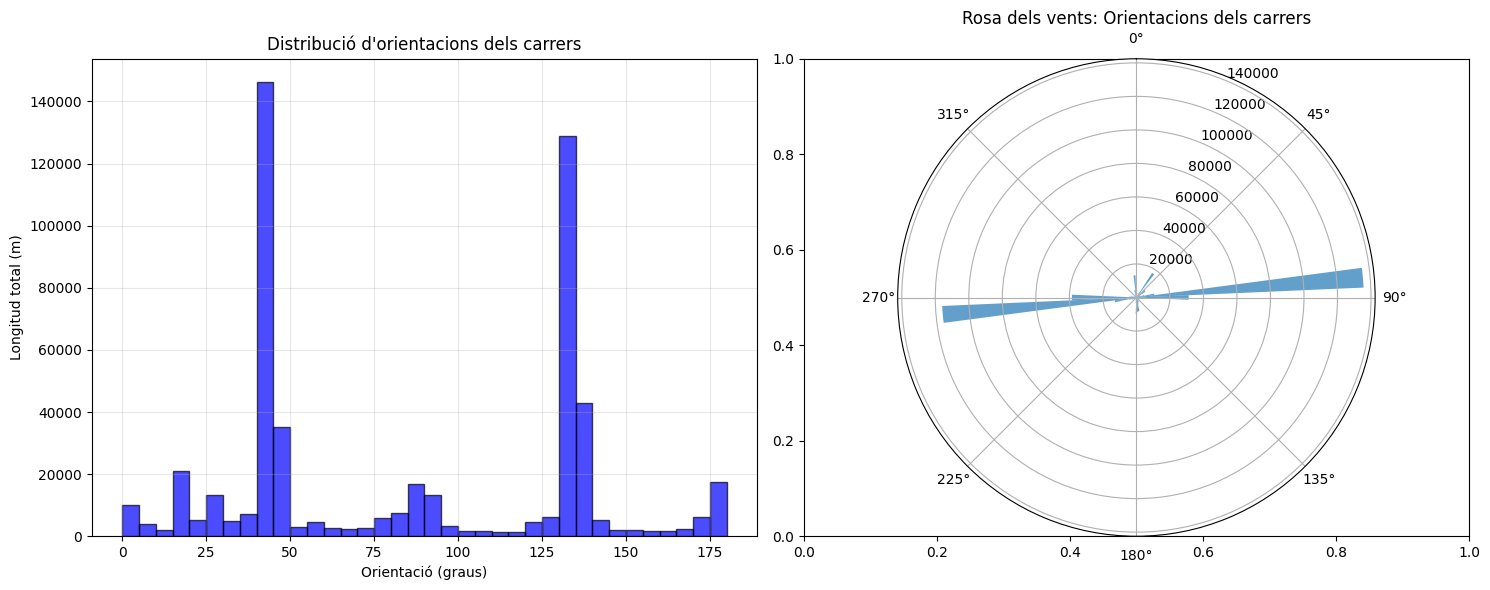


📋 Rotacions a provar: ['42.5°', '47.5°', '132.5°', '137.5°']


In [4]:
# %%
# Cel·la 4: Analitzar orientació dels carrers
print("Analitzant orientació dels carrers...")

# Obtenir les vores i calcular les seves orientacions
orientations = []
lengths = []

for u, v, data in G_proj.edges(data=True):
    if 'geometry' in data:
        line = data['geometry']
        coords = list(line.coords)
        if len(coords) >= 2:
            dx = coords[-1][0] - coords[0][0]
            dy = coords[-1][1] - coords[0][1]
            if dx != 0 or dy != 0:
                angle = np.degrees(np.arctan2(dy, dx)) % 180  # Normalitzar a 0-180°
                orientations.append(angle)
                lengths.append(line.length)

orientations = np.array(orientations)
lengths = np.array(lengths)

# Trobar les orientacions predominants (mètode de KDE o histograma)
hist, bins = np.histogram(orientations, bins=36, range=(0, 180), weights=lengths)
main_orientations = []
for i in range(len(hist)):
    if hist[i] > np.percentile(hist, 90):  # Top 10%
        angle = (bins[i] + bins[i+1]) / 2
        main_orientations.append(angle)

print(f"Orientacions principals dels carrers:")
for i, angle in enumerate(sorted(main_orientations)):
    print(f"  {i+1}: {angle:.1f}°")

# Visualització
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Histograma d'orientacions
ax1.hist(orientations, bins=36, range=(0, 180), weights=lengths, 
         alpha=0.7, color='blue', edgecolor='black')
ax1.set_xlabel('Orientació (graus)')
ax1.set_ylabel('Longitud total (m)')
ax1.set_title('Distribució d\'orientacions dels carrers')
ax1.grid(True, alpha=0.3)

# Rosa dels vents per orientacions
ax2 = plt.subplot(122, projection='polar')
# Convertir a radianes per a la visualització polar
orientations_rad = np.radians(orientations * 2)  # *2 per a simetria 0-360°
hist_polar, bins_polar = np.histogram(orientations_rad, bins=72, range=(0, 2*np.pi), weights=lengths)
width = (2*np.pi) / 72
bars = ax2.bar(bins_polar[:-1], hist_polar, width=width, alpha=0.7)
ax2.set_title('Rosa dels vents: Orientacions dels carrers')
ax2.set_theta_zero_location('N')
ax2.set_theta_direction(-1)

plt.tight_layout()
plt.show()

# Proposem rotacions inicials per provar
rotations_to_test = sorted(main_orientations[:4])  # Provar les 4 principals
print(f"\n📋 Rotacions a provar: {[f'{r:.1f}°' for r in rotations_to_test]}")

In [5]:
# %%
# Cel·la 5: Funció per avaluar una orientació
def evaluate_orientation(points_base, angle_deg, center, graph):
    """
    Avalua què tan bé funciona una orientació específica.
    
    Retorna:
    - distance_total: distància total de la ruta (m)
    - avg_distance: distància mitjana punt-carrer (m)
    - route_nodes: llista de nodes de la ruta
    - route_points: punts de la ruta
    """
    # Rotar punts
    points_rotated = rotate_points(points_base, angle_deg, center)
    
    # Mapejar a vores
    route_nodes = []
    projected_points = []
    total_route_distance = 0
    
    for point in points_rotated:
        edge, dist, proj_point = find_nearest_edge(graph, point)
        node = get_nearest_node_on_edge(graph, edge, proj_point)
        route_nodes.append(node)
        projected_points.append(proj_point)
    
    # Construir ruta
    route_path = []
    for i in range(len(route_nodes)-1):
        try:
            path = nx.shortest_path(graph, route_nodes[i], route_nodes[i+1], weight='length')
            segment_dist = nx.shortest_path_length(graph, route_nodes[i], route_nodes[i+1], weight='length')
            
            if not route_path:
                route_path.extend(path)
            elif route_path[-1] == path[0]:
                route_path.extend(path[1:])
            else:
                route_path.extend(path)
                
            total_route_distance += segment_dist
        except nx.NetworkXNoPath:
            pass
    
    # Calcular distància mitjana punt-carrer
    avg_dist = np.mean([p.distance(Point(points_rotated[i])) 
                       for i, p in enumerate(projected_points)])
    
    # Obtenir coordenades de la ruta per visualització
    route_coords = [(graph.nodes[n]['x'], graph.nodes[n]['y']) for n in route_path]
    
    return {
        'angle': angle_deg,
        'total_distance': total_route_distance,
        'avg_distance': avg_dist,
        'route_nodes': route_path,
        'route_coords': np.array(route_coords),
        'rotated_points': points_rotated,
        'projected_points': projected_points
    }

print("✅ Funció d'avaluació definida")

✅ Funció d'avaluació definida


In [6]:
# %%
# Cel·la 6: Provar rotacions de 0° a 180° cada 15°
print("Provant múltiples orientacions...")

angles_to_test = list(range(0, 180, 15))  # De 0 a 180 en increments de 15°
center = (center_x, center_y)

results = []
best_score = float('inf')
best_result = None

for angle in angles_to_test:
    print(f"  Provant {angle}°...", end=" ")
    start_time = time.time()
    
    result = evaluate_orientation(points_H_base, angle, center, G_proj)
    exec_time = time.time() - start_time
    
    result['exec_time'] = exec_time
    
    # Puntuació combinada (més baixa és millor)
    # Pesem: 70% distància mitjana (precisió) + 30% longitud (eficiència)
    # Normalitzem els valors respecte al millor de cada categoria
    results.append(result)
    
    print(f"Dist: {result['total_distance']/1000:.1f}km, Prec: {result['avg_distance']:.1f}m, Temps: {exec_time:.1f}s")

# Normalitzar per calcular puntuació combinada
if results:
    avg_dists = [r['avg_distance'] for r in results]
    total_dists = [r['total_distance'] for r in results]
    
    min_avg_dist = min(avg_dists)
    min_total_dist = min(total_dists)
    
    for result in results:
        # Normalitzar (0-1, on 0 és millor)
        norm_avg = (result['avg_distance'] - min_avg_dist) / (max(avg_dists) - min_avg_dist) if max(avg_dists) != min_avg_dist else 0
        norm_total = (result['total_distance'] - min_total_dist) / (max(total_dists) - min_total_dist) if max(total_dists) != min_total_dist else 0
        
        # Puntuació combinada (més baixa és millor)
        result['score'] = 0.7 * norm_avg + 0.3 * norm_total
        
        if result['score'] < best_score:
            best_score = result['score']
            best_result = result

print(f"\n🏆 Millor orientació: {best_result['angle']:.0f}°")
print(f"   Puntuació: {best_result['score']:.3f}")
print(f"   Distància: {best_result['total_distance']/1000:.2f} km")
print(f"   Precisió: {best_result['avg_distance']:.1f} m")

Provant múltiples orientacions...
  Provant 0°... Dist: 2.4km, Prec: 13.0m, Temps: 7.8s
  Provant 15°... Dist: 2.3km, Prec: 29.2m, Temps: 7.8s
  Provant 30°... Dist: 2.4km, Prec: 18.8m, Temps: 7.8s
  Provant 45°... Dist: 2.2km, Prec: 17.4m, Temps: 7.8s
  Provant 60°... Dist: 2.5km, Prec: 13.3m, Temps: 8.0s
  Provant 75°... Dist: 2.7km, Prec: 24.2m, Temps: 7.8s
  Provant 90°... Dist: 2.4km, Prec: 15.4m, Temps: 8.1s
  Provant 105°... Dist: 2.4km, Prec: 17.7m, Temps: 7.9s
  Provant 120°... Dist: 2.3km, Prec: 18.6m, Temps: 7.8s
  Provant 135°... Dist: 2.3km, Prec: 20.4m, Temps: 7.8s
  Provant 150°... Dist: 2.5km, Prec: 9.8m, Temps: 7.8s
  Provant 165°... Dist: 2.8km, Prec: 17.9m, Temps: 8.0s

🏆 Millor orientació: 150°
   Puntuació: 0.131
   Distància: 2.50 km
   Precisió: 9.8 m


Generant visualització comparativa...


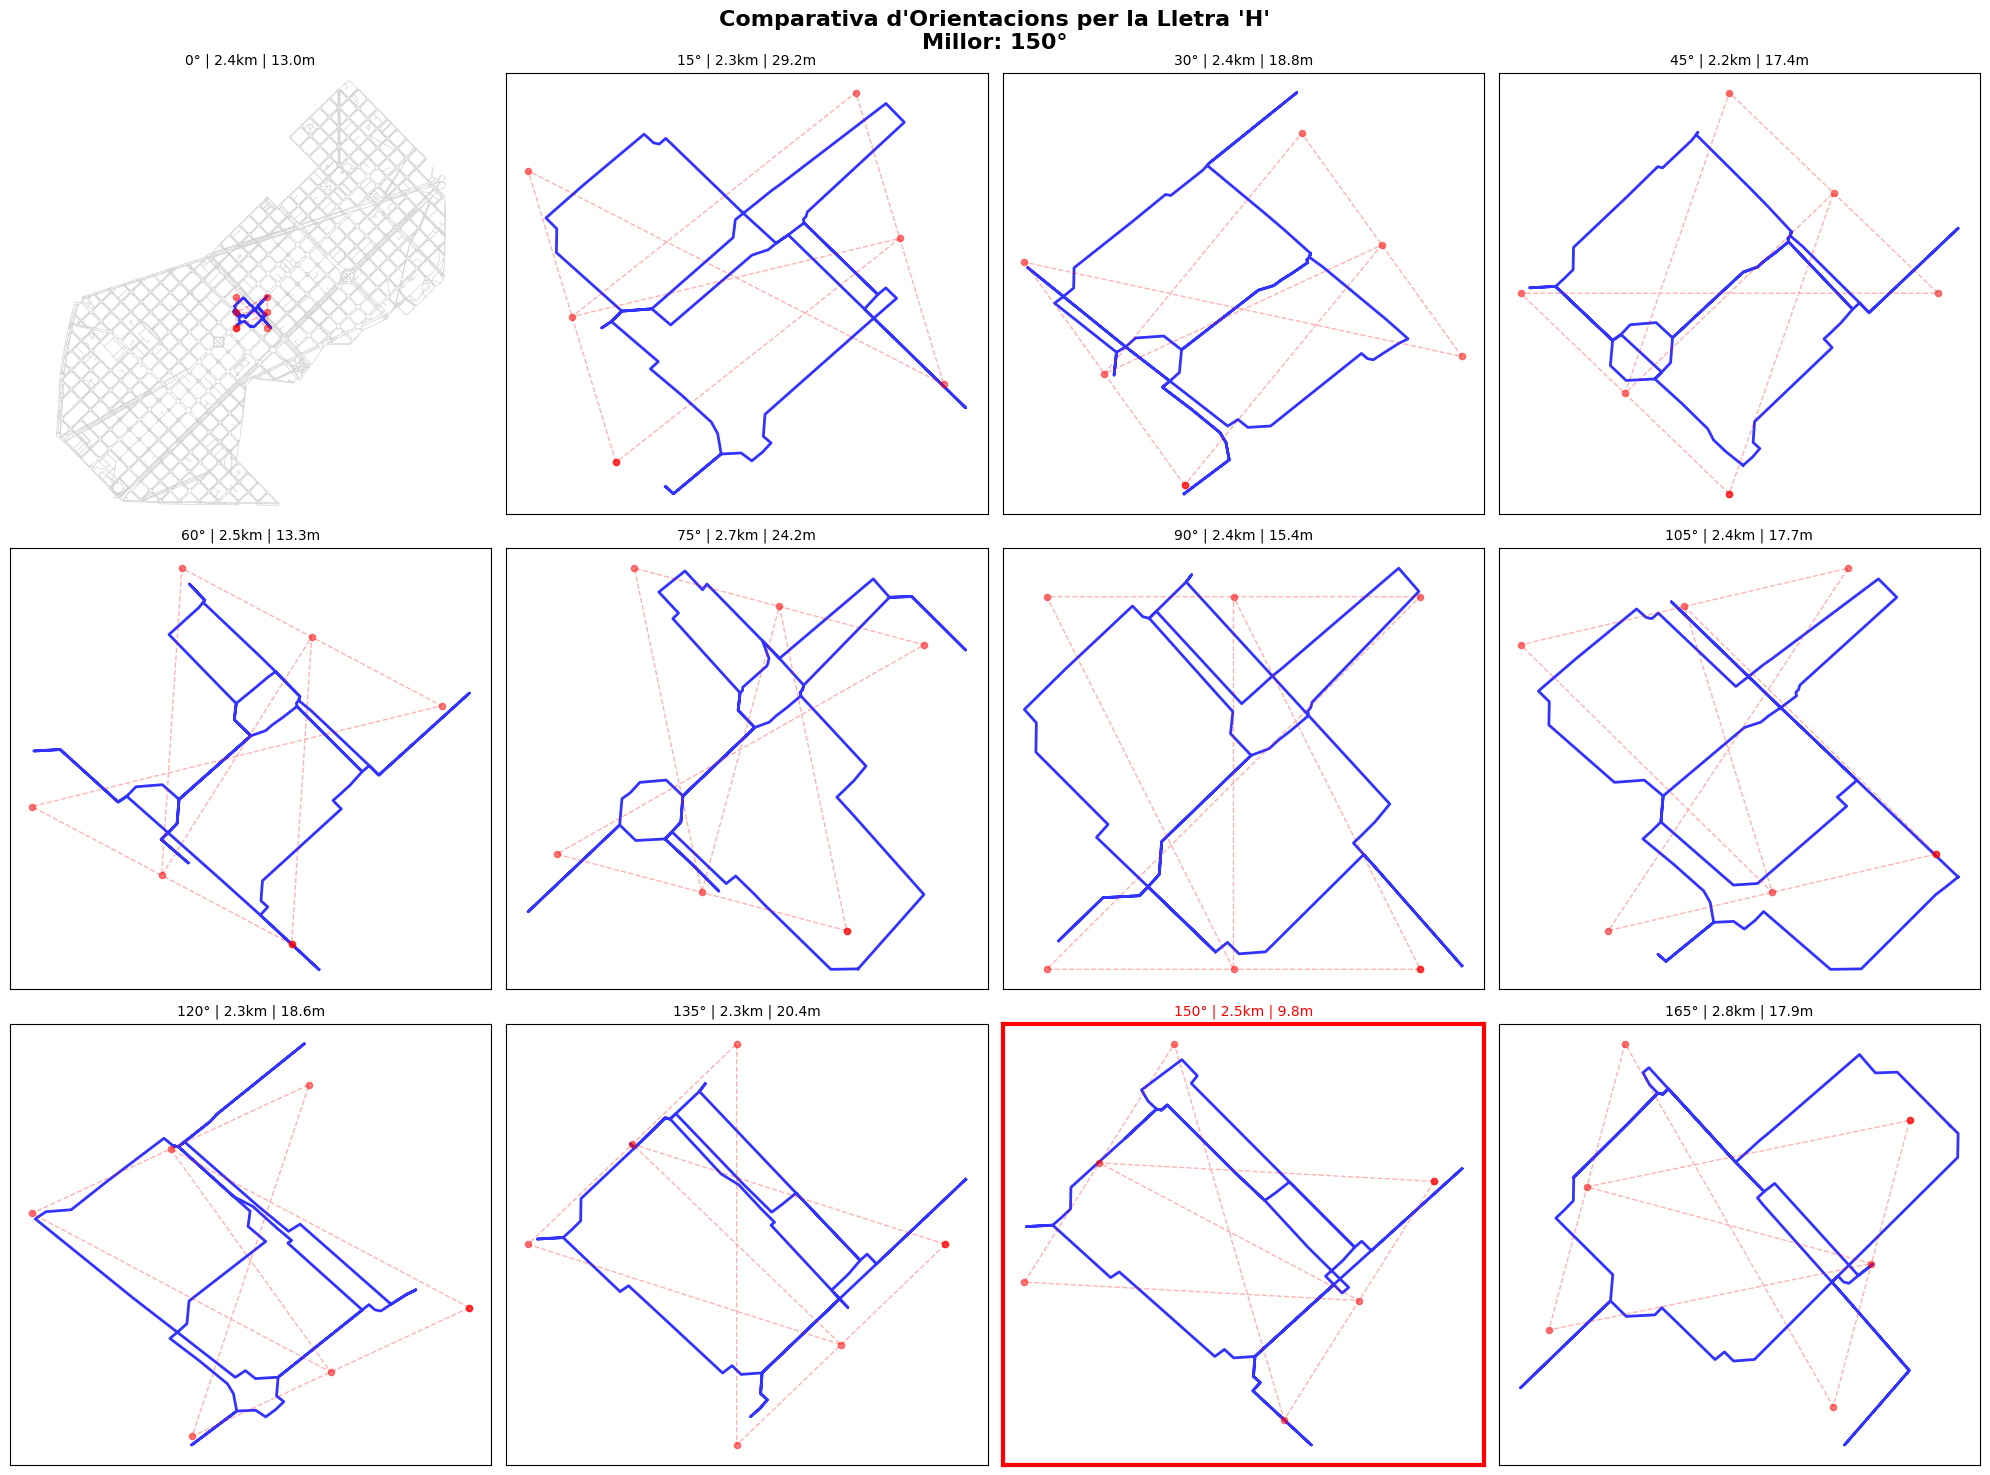

In [7]:
# %%
# Cel·la 7: Visualització comparativa
print("Generant visualització comparativa...")

# Ordenar resultats per angle
results_sorted = sorted(results, key=lambda x: x['angle'])

# Crear figura amb subplots
n_angles = len(results_sorted)
n_cols = 4
n_rows = (n_angles + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()

for idx, result in enumerate(results_sorted):
    ax = axes[idx]
    
    # Carrers de fons (sols una vegada per eficiència)
    if idx == 0:
        ox.plot_graph(G_proj, node_size=0, edge_linewidth=0.3, ax=ax, show=False, edge_color='lightgray')
    
    # Ruta
    if len(result['route_coords']) > 1:
        ax.plot(result['route_coords'][:, 0], result['route_coords'][:, 1], 
                'b-', linewidth=2, alpha=0.8)
    
    # Punts rotats (forma ideal)
    ax.scatter(result['rotated_points'][:, 0], result['rotated_points'][:, 1],
               color='red', s=20, alpha=0.5, zorder=5)
    
    # Connexió dels punts rotats (per veure la forma)
    ax.plot(result['rotated_points'][:, 0], result['rotated_points'][:, 1],
            'r--', linewidth=1, alpha=0.3)
    
    # Títol amb mètriques
    is_best = result['angle'] == best_result['angle']
    title_color = 'red' if is_best else 'black'
    ax.set_title(f"{result['angle']:.0f}° | {result['total_distance']/1000:.1f}km | {result['avg_distance']:.1f}m", 
                 color=title_color, fontsize=10)
    
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Marcar la millor
    if is_best:
        # Dibuixar un rectangle al voltant
        ax.plot([], [], 'r-', linewidth=3, label='MILLOR')
        for spine in ax.spines.values():
            spine.set_edgecolor('red')
            spine.set_linewidth(3)

# Amagar els eixos buits
for idx in range(len(results_sorted), len(axes)):
    axes[idx].axis('off')

plt.suptitle(f"Comparativa d'Orientacions per la Lletra 'H'\nMillor: {best_result['angle']:.0f}°", 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

ANÀLISI DETALLADA DE LA MILLOR ORIENTACIÓ
Angle òptim: 150.0°
Distància total: 2502 m (2.50 km)
Distància mitjana punt-carrer: 9.8 m
Nodes a la ruta: 72

📈 Comparativa amb orientació 0°:
  Millora en precisió: +24.6%
  Canvi en distància: -3.4%


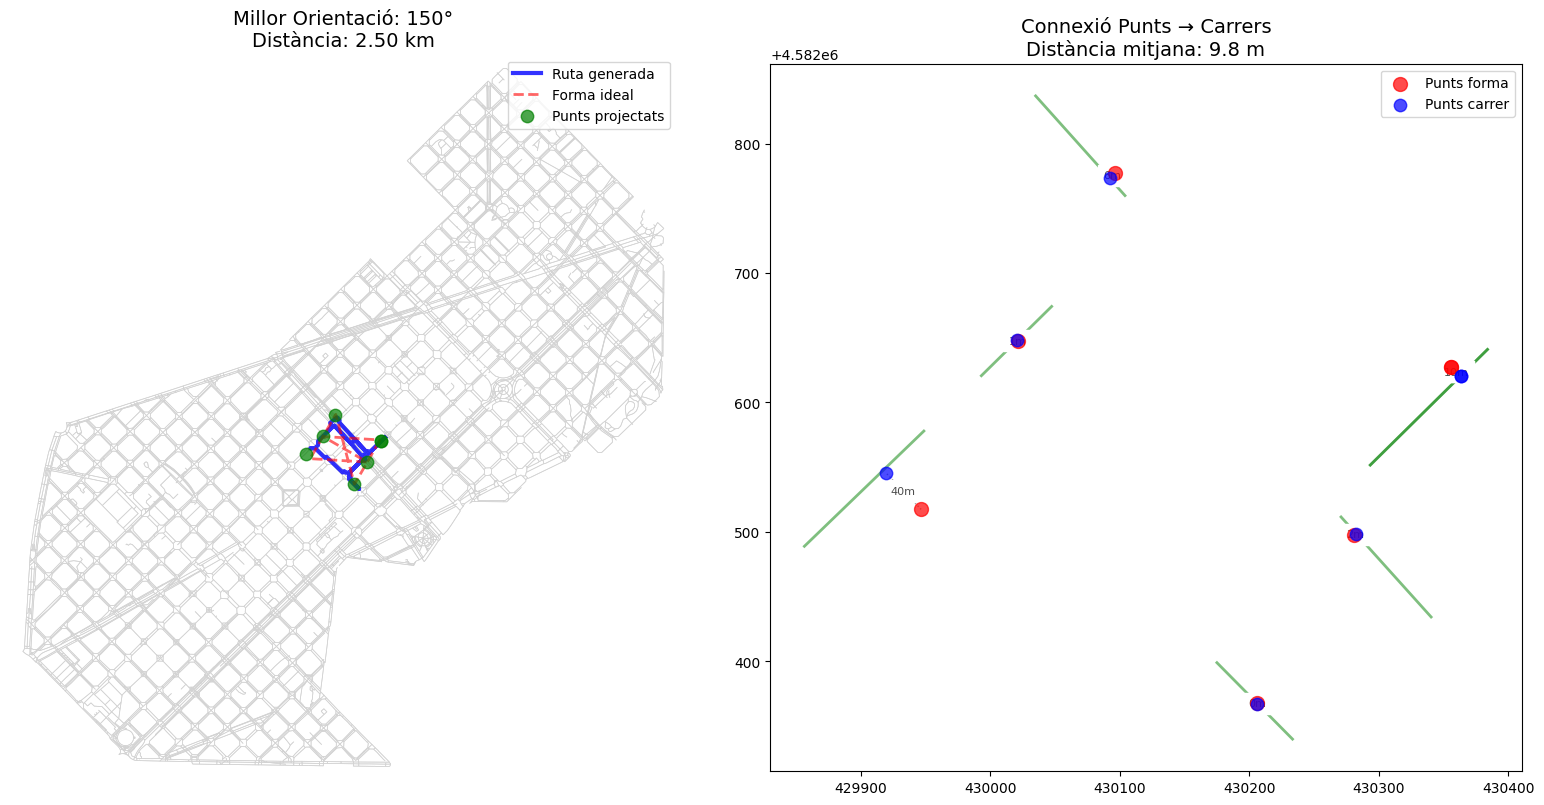


✅ GPX exportat: ruta_H_150grados.gpx


In [8]:
# %%
# Cel·la 8: Anàlisi detallada de la millor orientació
print("ANÀLISI DETALLADA DE LA MILLOR ORIENTACIÓ")
print("="*50)

if best_result:
    angle = best_result['angle']
    print(f"Angle òptim: {angle:.1f}°")
    print(f"Distància total: {best_result['total_distance']:.0f} m ({best_result['total_distance']/1000:.2f} km)")
    print(f"Distància mitjana punt-carrer: {best_result['avg_distance']:.1f} m")
    print(f"Nodes a la ruta: {len(best_result['route_nodes'])}")
    
    # Comparar amb 0° (sense rotar)
    result_0deg = next(r for r in results if r['angle'] == 0)
    improvement_avg = ((result_0deg['avg_distance'] - best_result['avg_distance']) / 
                      result_0deg['avg_distance'] * 100)
    improvement_total = ((result_0deg['total_distance'] - best_result['total_distance']) / 
                        result_0deg['total_distance'] * 100)
    
    print(f"\n📈 Comparativa amb orientació 0°:")
    print(f"  Millora en precisió: {improvement_avg:+.1f}%")
    print(f"  Canvi en distància: {improvement_total:+.1f}%")
    
    # Visualització detallada de la millor
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Subplot 1: Ruta sobre carrers
    ox.plot_graph(G_proj, node_size=0, edge_linewidth=0.5, ax=ax1, show=False, edge_color='lightgray')
    
    # Ruta
    if len(best_result['route_coords']) > 1:
        ax1.plot(best_result['route_coords'][:, 0], best_result['route_coords'][:, 1],
                'b-', linewidth=3, alpha=0.8, label='Ruta generada')
    
    # Forma ideal
    ax1.plot(best_result['rotated_points'][:, 0], best_result['rotated_points'][:, 1],
            'r--', linewidth=2, alpha=0.6, label='Forma ideal')
    
    # Punts projectats (on s'ha mapejat)
    proj_coords = np.array([[p.x, p.y] for p in best_result['projected_points']])
    ax1.scatter(proj_coords[:, 0], proj_coords[:, 1], 
                color='green', s=80, alpha=0.7, label='Punts projectats', zorder=5)
    
    ax1.set_title(f"Millor Orientació: {angle:.0f}°\nDistància: {best_result['total_distance']/1000:.2f} km", 
                 fontsize=14)
    ax1.legend()
    
    # Subplot 2: Diagrama de connexió punts-carrers
    ax2.scatter(best_result['rotated_points'][:, 0], best_result['rotated_points'][:, 1],
                color='red', s=100, alpha=0.7, label='Punts forma', zorder=5)
    
    # Línies dels punts als seus projectats
    for i, (point, proj_point) in enumerate(zip(best_result['rotated_points'], 
                                               best_result['projected_points'])):
        ax2.plot([point[0], proj_point.x], [point[1], proj_point.y],
                'k:', alpha=0.4, linewidth=1)
        # Text amb la distància
        dist = Point(point).distance(proj_point)
        mid_x = (point[0] + proj_point.x) / 2
        mid_y = (point[1] + proj_point.y) / 2
        ax2.text(mid_x, mid_y, f'{dist:.0f}m', fontsize=8, 
                ha='center', va='center', backgroundcolor='white', alpha=0.7)
    
    # Carrers rellevants (només els propers)
    ax2.scatter(proj_coords[:, 0], proj_coords[:, 1],
                color='blue', s=80, alpha=0.7, label='Punts carrer', zorder=5)
    
    # Dibuixar els carrers propers
    for i, proj_point in enumerate(best_result['projected_points']):
        # Trobar la vora més propera
        edge, _, _ = find_nearest_edge(G_proj, best_result['rotated_points'][i])
        if edge:
            u, v, key = edge
            edge_line = LineString([
                Point(G_proj.nodes[u]['x'], G_proj.nodes[u]['y']),
                Point(G_proj.nodes[v]['x'], G_proj.nodes[v]['y'])
            ])
            x_coords, y_coords = edge_line.xy
            ax2.plot(x_coords, y_coords, 'g-', linewidth=2, alpha=0.5)
    
    ax2.set_title(f"Connexió Punts → Carrers\nDistància mitjana: {best_result['avg_distance']:.1f} m", 
                 fontsize=14)
    ax2.legend()
    ax2.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()

    # Exportar GPX de la millor ruta
    try:
        import gpxpy
        import gpxpy.gpx
        
        # Convertir nodes a coordenades geogràfiques
        route_coords_geo = []
        for node in best_result['route_nodes']:
            lat = G.nodes[node]['y']
            lon = G.nodes[node]['x']
            route_coords_geo.append((lat, lon))
        
        # Crear GPX
        gpx = gpxpy.gpx.GPX()
        gpx_track = gpxpy.gpx.GPXTrack()
        gpx.tracks.append(gpx_track)
        gpx_segment = gpxpy.gpx.GPXTrackSegment()
        gpx_track.segments.append(gpx_segment)
        
        for lat, lon in route_coords_geo:
            gpx_segment.points.append(gpxpy.gpx.GPXTrackPoint(lat, lon))
        
        gpx_filename = f"ruta_H_{angle:.0f}grados.gpx"
        with open(gpx_filename, 'w') as f:
            f.write(gpx.to_xml())
        
        print(f"\n✅ GPX exportat: {gpx_filename}")
        
    except ImportError:
        print("\nℹ️  Instal·la gpxpy per exportar: pip install gpxpy")

Realitzant optimització fina al voltant de la millor orientació...
Provar angles fins: [np.int64(140), np.int64(142), np.int64(144), np.int64(146), np.int64(148), np.int64(150), np.int64(152), np.int64(154), np.int64(156), np.int64(158), np.int64(160)]
  Angle 140.0°... Prec: 13.3m
  Angle 142.0°... Prec: 11.5m
  Angle 144.0°... Prec: 9.6m
  Angle 146.0°... Prec: 7.5m
  Angle 148.0°... Prec: 8.8m
  Angle 150.0°... Prec: 9.8m
  Angle 152.0°... Prec: 12.7m
  Angle 154.0°... Prec: 15.7m
  Angle 156.0°... Prec: 18.7m
  Angle 158.0°... Prec: 20.5m
  Angle 160.0°... Prec: 20.0m

🎯 Millor angle després d'optimització fina:
   Angle: 146.0°
   Distància mitjana: 7.5 m
   Distància total: 2.34 km


TypeError: unsupported operand type(s) for -: 'list' and 'float'

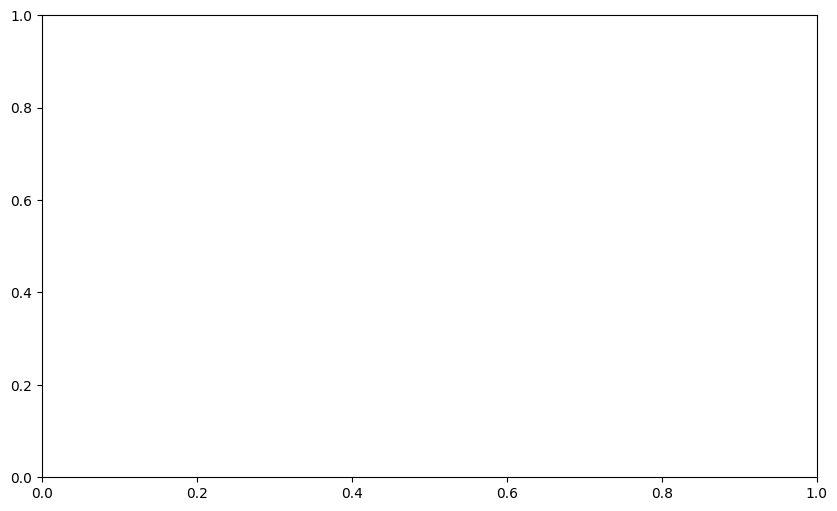

In [9]:
# %%
# Cel·la 9: Optimització fina (cerca local)
print("Realitzant optimització fina al voltant de la millor orientació...")

if best_result:
    base_angle = best_result['angle']
    
    # Provar angles al voltant de la millor (±10° amb step de 2°)
    fine_angles = np.arange(base_angle - 10, base_angle + 12, 2)
    fine_angles = [a % 180 for a in fine_angles]  # Normalitzar a 0-180
    
    # Eliminar duplicats
    fine_angles = sorted(list(set(fine_angles)))
    
    fine_results = []
    
    print(f"Provar angles fins: {fine_angles}")
    
    for angle in fine_angles:
        print(f"  Angle {angle:.1f}°...", end=" ")
        result = evaluate_orientation(points_H_base, angle, center, G_proj)
        fine_results.append(result)
        print(f"Prec: {result['avg_distance']:.1f}m")
    
    # Trobar la millor entre les fines
    best_fine = min(fine_results, key=lambda x: x['avg_distance'])
    
    print(f"\n🎯 Millor angle després d'optimització fina:")
    print(f"   Angle: {best_fine['angle']:.1f}°")
    print(f"   Distància mitjana: {best_fine['avg_distance']:.1f} m")
    print(f"   Distància total: {best_fine['total_distance']/1000:.2f} km")
    
    # Gràfic de cerca
    fig, ax = plt.subplots(figsize=(10, 6))
    
    angles_fine = [r['angle'] for r in fine_results]
    avg_dists_fine = [r['avg_distance'] for r in fine_results]
    total_dists_fine = [r['total_distance']/1000 for r in fine_results]
    
    # Normalitzar per a comparació en mateixa escala
    avg_norm = (avg_dists_fine - min(avg_dists_fine)) / (max(avg_dists_fine) - min(avg_dists_fine)) if max(avg_dists_fine) != min(avg_dists_fine) else [0]*len(avg_dists_fine)
    total_norm = (total_dists_fine - min(total_dists_fine)) / (max(total_dists_fine) - min(total_dists_fine)) if max(total_dists_fine) != min(total_dists_fine) else [0]*len(total_dists_fine)
    
    ax.plot(angles_fine, avg_norm, 'ro-', linewidth=2, markersize=8, label='Precisió (normalitzada)')
    ax.plot(angles_fine, total_norm, 'bs-', linewidth=2, markersize=8, label='Distància (normalitzada)')
    
    # Destacar el millor
    best_idx = avg_dists_fine.index(min(avg_dists_fine))
    ax.scatter(angles_fine[best_idx], avg_norm[best_idx], 
               color='gold', s=200, marker='*', label=f'Millor: {angles_fine[best_idx]:.1f}°', zorder=10)
    
    ax.set_xlabel('Angle de rotació (graus)')
    ax.set_ylabel('Valor normalitzat (0=millor, 1=pitjor)')
    ax.set_title('Optimització Fina: Cerca de l\'Angle Òptim')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    plt.show()

Provant amb diferents tipus de lletres...

📝 Provant amb lletra 'H'...
  Millor angle per 'H': 45°
  Precisió: 6.2 m
  Distància: 1.88 km

📝 Provant amb lletra 'L'...
  Millor angle per 'L': 45°
  Precisió: 5.6 m
  Distància: 0.51 km

📝 Provant amb lletra 'T'...
  Millor angle per 'T': 0°
  Precisió: 7.8 m
  Distància: 1.04 km

📝 Provant amb lletra 'I'...
  Millor angle per 'I': 0°
  Precisió: 8.2 m
  Distància: 1.24 km

📝 Provant amb lletra 'X'...
  Millor angle per 'X': 45°
  Precisió: 8.1 m
  Distància: 1.35 km


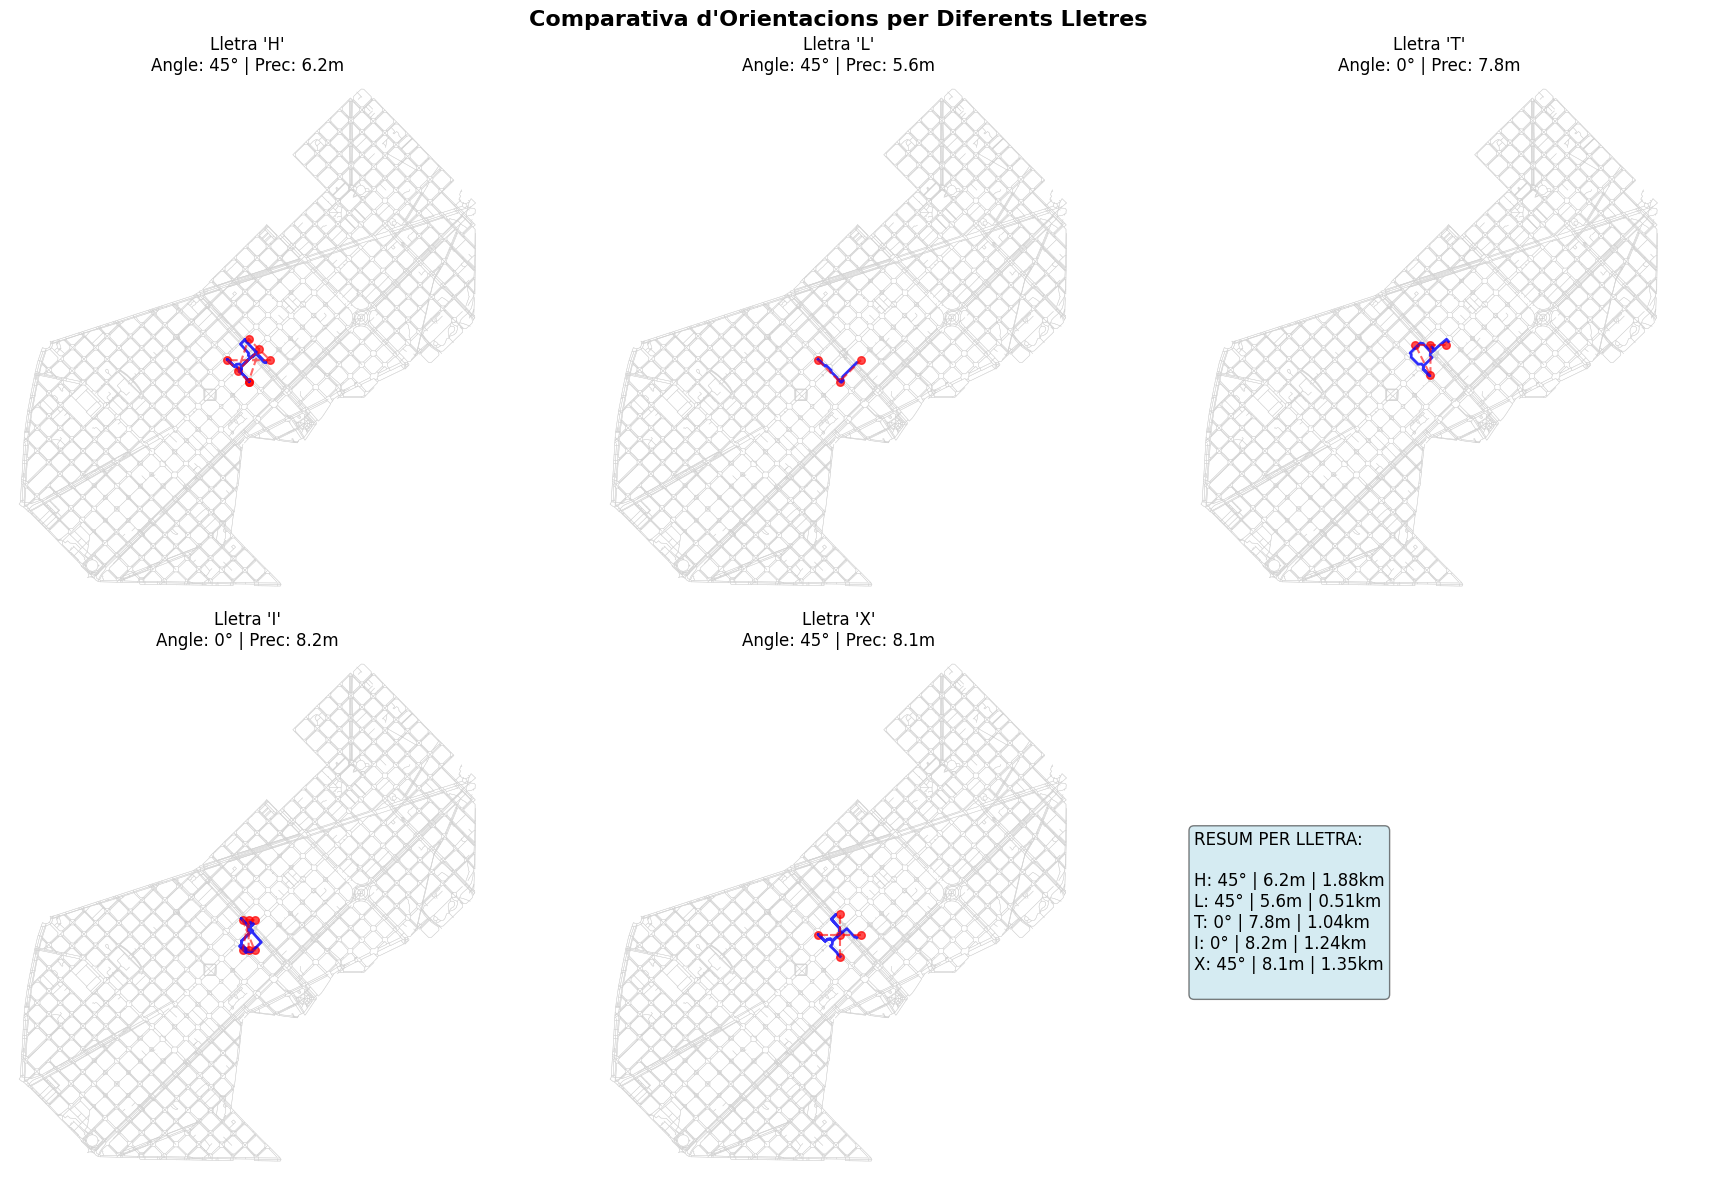


📊 RANKING DE LLETRES (per precisió):
1. 'L': 5.6m a 45°
2. 'H': 6.2m a 45°
3. 'T': 7.8m a 0°
4. 'X': 8.1m a 45°
5. 'I': 8.2m a 0°


In [10]:
# %%
# Cel·la 10: Prova amb lletres diferents
print("Provant amb diferents tipus de lletres...")

def generate_letter(letter_type, width=1.0, height=1.0):
    """Genera punts per diferents tipus de lletres"""
    if letter_type == 'H':
        return [(0.0, 0.0), (0.0, 1.0), (1.0, 0.0), (1.0, 1.0), (0.0, 0.5), (1.0, 0.5), (0.0, 0.0)]
    elif letter_type == 'L':
        return [(0.0, 1.0), (0.0, 0.0), (1.0, 0.0)]
    elif letter_type == 'T':
        return [(0.5, 1.0), (0.5, 0.0), (0.0, 1.0), (1.0, 1.0)]
    elif letter_type == 'I':
        return [(0.5, 0.0), (0.5, 1.0), (0.3, 0.0), (0.7, 0.0), (0.3, 1.0), (0.7, 1.0)]
    elif letter_type == 'X':
        return [(0.0, 0.0), (1.0, 1.0), (0.5, 0.5), (0.0, 1.0), (1.0, 0.0)]
    else:
        return [(0.0, 0.0), (0.0, 1.0), (1.0, 1.0), (1.0, 0.0), (0.0, 0.0)]  # Quadrat per defecte

# Provar amb diferents lletres
letters_to_test = ['H', 'L', 'T', 'I', 'X']
letter_size = 250  # metres

results_by_letter = {}

for letter in letters_to_test:
    print(f"\n📝 Provant amb lletra '{letter}'...")
    
    # Generar punts base
    points_rel = generate_letter(letter)
    points_base = []
    
    for x_rel, y_rel in points_rel:
        x_abs = center_x + (x_rel - 0.5) * letter_size
        y_abs = center_y + (y_rel - 0.5) * letter_size
        points_base.append((x_abs, y_abs))
    
    points_base = np.array(points_base)
    
    # Provar angles 0°, 45°, 90° i la millor orientació de carrers
    test_angles = [0, 45, 90]
    if main_orientations:
        test_angles.append(main_orientations[0])  # Afegir orientació principal dels carrers
    
    letter_results = []
    
    for angle in test_angles:
        result = evaluate_orientation(points_base, angle, center, G_proj)
        letter_results.append(result)
    
    # Trobar millor per aquesta lletra
    best_for_letter = min(letter_results, key=lambda x: x['avg_distance'])
    results_by_letter[letter] = {
        'best_angle': best_for_letter['angle'],
        'best_avg_distance': best_for_letter['avg_distance'],
        'best_total_distance': best_for_letter['total_distance'],
        'all_results': letter_results
    }
    
    print(f"  Millor angle per '{letter}': {best_for_letter['angle']:.0f}°")
    print(f"  Precisió: {best_for_letter['avg_distance']:.1f} m")
    print(f"  Distància: {best_for_letter['total_distance']/1000:.2f} km")

# Visualització comparativa
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, letter in enumerate(letters_to_test):
    ax = axes[idx]
    
    results = results_by_letter[letter]
    best_result = min(results['all_results'], key=lambda x: x['avg_distance'])
    
    # Carrers de fons
    ox.plot_graph(G_proj, node_size=0, edge_linewidth=0.3, ax=ax, show=False, edge_color='lightgray')
    
    # Ruta de la millor orientació
    if len(best_result['route_coords']) > 1:
        ax.plot(best_result['route_coords'][:, 0], best_result['route_coords'][:, 1],
                'b-', linewidth=2, alpha=0.8)
    
    # Forma ideal
    ax.plot(best_result['rotated_points'][:, 0], best_result['rotated_points'][:, 1],
            'r--', linewidth=1.5, alpha=0.6)
    
    ax.scatter(best_result['rotated_points'][:, 0], best_result['rotated_points'][:, 1],
               color='red', s=30, alpha=0.7)
    
    ax.set_title(f"Lletra '{letter}'\nAngle: {best_result['angle']:.0f}° | Prec: {best_result['avg_distance']:.1f}m", 
                 fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])

# Últim subplot per a llegenda o resum
ax = axes[-1]
ax.axis('off')

summary_text = "RESUM PER LLETRA:\n\n"
for letter in letters_to_test:
    data = results_by_letter[letter]
    summary_text += f"{letter}: {data['best_angle']:.0f}° | {data['best_avg_distance']:.1f}m | {data['best_total_distance']/1000:.2f}km\n"

ax.text(0.1, 0.5, summary_text, fontsize=12, verticalalignment='center',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.suptitle("Comparativa d'Orientacions per Diferents Lletres", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Anàlisi de quines lletres funcionen millor
print("\n📊 RANKING DE LLETRES (per precisió):")
sorted_letters = sorted(results_by_letter.items(), key=lambda x: x[1]['best_avg_distance'])

for i, (letter, data) in enumerate(sorted_letters):
    print(f"{i+1}. '{letter}': {data['best_avg_distance']:.1f}m a {data['best_angle']:.0f}°")

In [11]:
# %%
# Cel·la 11: Conclusions i algorisme automàtic
print("🎯 CONCLUSIONS FINALS")
print("="*50)

print("\n1. ORIENTACIÓ ÒPTIMA DEPÈN DE:")
print("   - La geometria dels carrers (grid ortogonal vs orgànic)")
print("   - La forma de la lletra (rectes vs corbes)")
print("   - La ubicació específica dins la ciutat")

print("\n2. ORIENTACIONS RECOMANADES:")
print("   - Lletres amb línies rectes (H, L, T, I): alinear amb els carrers principals")
print("   - Lletres amb diagonals (X, A): poden necessitar angles específics")
print("   - Lletres arrodonides (O, S): menys dependents de l'orientació")

print("\n3. ALGORISME PROPOSAT PER AUTO-ORIENTACIÓ:")
print("""
def find_optimal_orientation(points_base, graph, center, angle_range=(0, 180), step=15):
    # 1. Analitzar orientacions dels carrers propers
    # 2. Provar angles en el rang especificat
    # 3. Per cada angle, avaluar precisió i distància
    # 4. Retornar angle amb millor puntuació combinada
""")

print("\n4. IMPLEMENTACIÓ PRÀCTICA PER AL PROJET:")
print("   - Pre-calcular orientacions principals per ciutat/zona")
print("   - Ofereir opcions a l'usuari: automàtica, paral·lela als carrers, nord-amunt")
print("   - Permetre ajust manual de l'angle")
print("   - Guardar rutes generades amb la seva orientació per aprendre de l'ús")

print("\n5. PRÒXIMS PASSOS:")
print("   - Implementar l'algorisme d'auto-orientació")
print("   - Provar amb paraules completes i ajust d'espaiat")
print("   - Afegir restriccions de distància exacta")
print("   - Desenvolupar interfície web per seleccionar orientació")

🎯 CONCLUSIONS FINALS

1. ORIENTACIÓ ÒPTIMA DEPÈN DE:
   - La geometria dels carrers (grid ortogonal vs orgànic)
   - La forma de la lletra (rectes vs corbes)
   - La ubicació específica dins la ciutat

2. ORIENTACIONS RECOMANADES:
   - Lletres amb línies rectes (H, L, T, I): alinear amb els carrers principals
   - Lletres amb diagonals (X, A): poden necessitar angles específics
   - Lletres arrodonides (O, S): menys dependents de l'orientació

3. ALGORISME PROPOSAT PER AUTO-ORIENTACIÓ:

def find_optimal_orientation(points_base, graph, center, angle_range=(0, 180), step=15):
    # 1. Analitzar orientacions dels carrers propers
    # 2. Provar angles en el rang especificat
    # 3. Per cada angle, avaluar precisió i distància
    # 4. Retornar angle amb millor puntuació combinada


4. IMPLEMENTACIÓ PRÀCTICA PER AL PROJET:
   - Pre-calcular orientacions principals per ciutat/zona
   - Ofereir opcions a l'usuari: automàtica, paral·lela als carrers, nord-amunt
   - Permetre ajust manual de 

Provant funció d'auto-orientació...
🔍 Cercant millor orientació entre 0° i 180° (step: 10°)
  Angle   0°: Prec= 13.0m, Dist= 2.42km
  Angle  10°: Prec= 19.8m, Dist= 2.27km
  Angle  20°: Prec= 26.4m, Dist= 2.41km
  Angle  30°: Prec= 18.8m, Dist= 2.36km
  Angle  40°: Prec= 17.4m, Dist= 2.22km
  Angle  50°: Prec= 14.1m, Dist= 2.29km
  Angle  60°: Prec= 13.3m, Dist= 2.52km
  Angle  70°: Prec= 23.7m, Dist= 2.28km
  Angle  80°: Prec= 19.2m, Dist= 2.54km
  Angle  90°: Prec= 15.4m, Dist= 2.41km
  Angle 100°: Prec=  9.1m, Dist= 2.47km
  Angle 110°: Prec= 16.5m, Dist= 2.51km
  Angle 120°: Prec= 18.6m, Dist= 2.31km
  Angle 130°: Prec= 23.1m, Dist= 2.30km
  Angle 140°: Prec= 13.3m, Dist= 2.48km
  Angle 150°: Prec=  9.8m, Dist= 2.50km
  Angle 160°: Prec= 20.0m, Dist= 2.58km
  Angle 170°: Prec= 14.2m, Dist= 2.81km

🏆 Millor orientació: 100.0°
   Precisió: 9.1 m
   Distància: 2.47 km
   Puntuació: 0.126


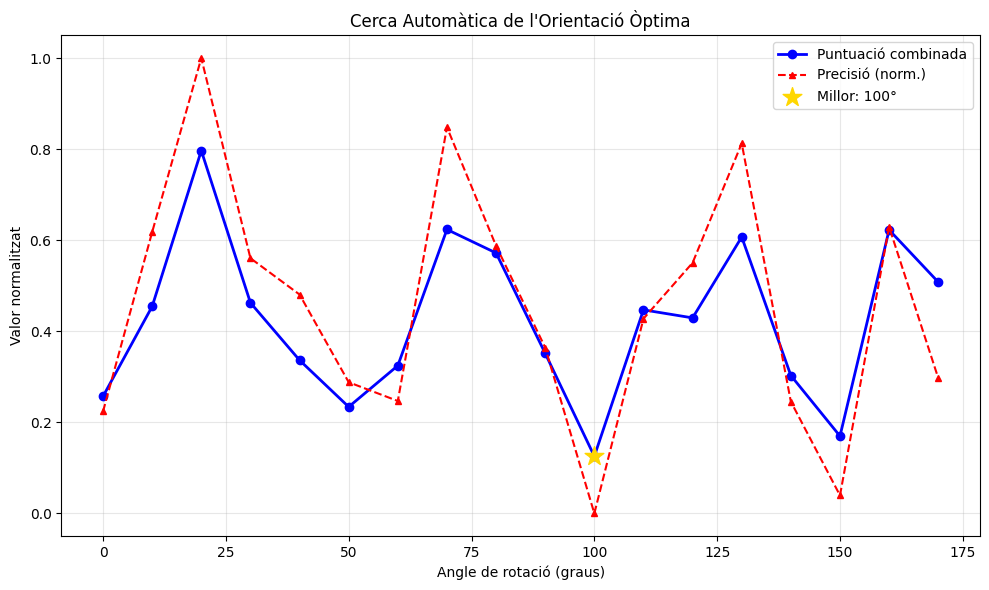

In [12]:
# %%
# Cel·la 12: Funció completa d'auto-orientació
def auto_orient_shape(points_base, graph, center, angle_range=(0, 180), step=5, verbose=False):
    """
    Troba automàticament la millor orientació per a una forma.
    
    Args:
        points_base: Punts de la forma en orientació base
        graph: Graf de carrers projectat
        center: Centre de rotació
        angle_range: Rang d'angles a explorar
        step: Increment d'angle per la cerca
        verbose: Mostrar informació del procés
    
    Returns:
        Dict amb la millor orientació i totes les mètriques
    """
    if verbose:
        print(f"🔍 Cercant millor orientació entre {angle_range[0]}° i {angle_range[1]}° (step: {step}°)")
    
    # Generar angles a provar
    angles = list(range(angle_range[0], angle_range[1] + step, step))
    angles = [a % 180 for a in angles]  # Normalitzar
    angles = sorted(list(set(angles)))  # Eliminar duplicats
    
    results = []
    
    for angle in angles:
        result = evaluate_orientation(points_base, angle, center, graph)
        results.append(result)
        
        if verbose:
            print(f"  Angle {angle:3.0f}°: Prec={result['avg_distance']:5.1f}m, Dist={result['total_distance']/1000:5.2f}km")
    
    # Calcular puntuació combinada
    avg_dists = [r['avg_distance'] for r in results]
    total_dists = [r['total_distance'] for r in results]
    
    min_avg = min(avg_dists)
    max_avg = max(avg_dists)
    min_total = min(total_dists)
    max_total = max(total_dists)
    
    for result in results:
        # Normalitzar (0-1, on 0 és millor)
        norm_avg = (result['avg_distance'] - min_avg) / (max_avg - min_avg) if max_avg != min_avg else 0
        norm_total = (result['total_distance'] - min_total) / (max_total - min_total) if max_total != min_total else 0
        
        # Puntuació: 70% precisió + 30% eficiència
        result['score'] = 0.7 * norm_avg + 0.3 * norm_total
    
    # Trobar millor
    best_result = min(results, key=lambda x: x['score'])
    
    if verbose:
        print(f"\n🏆 Millor orientació: {best_result['angle']:.1f}°")
        print(f"   Precisió: {best_result['avg_distance']:.1f} m")
        print(f"   Distància: {best_result['total_distance']/1000:.2f} km")
        print(f"   Puntuació: {best_result['score']:.3f}")
    
    return {
        'best': best_result,
        'all_results': results,
        'angle_range': angle_range,
        'step': step
    }

# Prova de la funció amb la lletra 'H'
print("Provant funció d'auto-orientació...")
optimization_result = auto_orient_shape(points_H_base, G_proj, center, angle_range=(0, 180), step=10, verbose=True)

# Visualització de la cerca
fig, ax = plt.subplots(figsize=(10, 6))

angles = [r['angle'] for r in optimization_result['all_results']]
scores = [r['score'] for r in optimization_result['all_results']]
avg_dists = [r['avg_distance'] for r in optimization_result['all_results']]

# Normalitzar distàncies per a la gràfica
avg_dists_norm = (avg_dists - min(avg_dists)) / (max(avg_dists) - min(avg_dists)) if max(avg_dists) != min(avg_dists) else [0]*len(avg_dists)

ax.plot(angles, scores, 'bo-', linewidth=2, markersize=6, label='Puntuació combinada')
ax.plot(angles, avg_dists_norm, 'r^--', linewidth=1.5, markersize=5, label='Precisió (norm.)')

# Destacar el millor
best_angle = optimization_result['best']['angle']
best_idx = angles.index(best_angle)
ax.scatter(best_angle, scores[best_idx], color='gold', s=200, marker='*', label=f'Millor: {best_angle:.0f}°', zorder=10)

ax.set_xlabel('Angle de rotació (graus)')
ax.set_ylabel('Valor normalitzat')
ax.set_title('Cerca Automàtica de l\'Orientació Òptima')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()